# 📊 Sales Data — Exploratory Data Analysis (EDA)

This notebook explores the processed sales data warehouse tables.
It covers:
- Dataset overview & shape
- Missing value and duplicate checks
- Sales distribution analysis
- Revenue & profit trends
- Regional and product breakdowns
- Customer behaviour insights
- Correlation analysis

**Run the ETL pipeline first:** `python main.py`


## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 110, "font.size": 11})

# Load processed tables
fact     = pd.read_csv("../data/processed/fact_sales.csv")
dim_prod = pd.read_csv("../data/processed/dim_product.csv")
dim_date = pd.read_csv("../data/processed/dim_date.csv")
dim_cust = pd.read_csv("../data/processed/dim_customer.csv")

# Build enriched flat table
df = fact.merge(dim_prod, on="product_id")
df = df.merge(dim_date,  on="date_id")
df = df.merge(dim_cust,  on="customer_id")

print(f"Total rows : {len(df):,}")
print(f"Columns    : {df.columns.tolist()}")
df.head()


Total rows : 1,000
Columns    : ['order_id', 'date_id', 'product_id', 'customer_id', 'region', 'quantity', 'unit_price', 'unit_cost', 'total_amount', 'total_cost', 'profit', 'profit_margin_pct', 'status', 'product_name', 'category', 'full_date', 'year', 'quarter', 'month', 'month_name', 'week', 'day', 'weekday', 'is_weekend', 'customer_name', 'customer_email', 'customer_type']


,order_id,date_id,product_id,customer_id,region,quantity,unit_price,unit_cost,total_amount,total_cost,...,quarter,month,month_name,week,day,weekday,is_weekend,customer_name,customer_email,customer_type
0,1001,1,1,1,East,4,32.48,11.52,129.92,46.08,...,4,10,October,40,7,Saturday,True,Alice Johnson,alice@example.com,Enterprise
1,1002,2,1,2,West,1,32.16,11.68,32.16,11.68,...,4,11,November,44,5,Sunday,True,Jack Wilson,jack@example.com,SMB
2,1003,3,2,3,South,7,1132.91,807.14,7930.37,5649.98,...,1,1,January,1,4,Wednesday,False,Isla Thomas,isla@example.com,Individual
3,1004,4,3,4,West,5,51.21,20.91,256.05,104.55,...,2,6,June,25,22,Thursday,False,Liam Taylor,liam@example.com,Individual
4,1005,5,1,5,West,6,37.43,12.12,224.58,72.72,...,1,1,January,4,23,Monday,False,Bob Smith,bob@example.com,SMB


## 2. Dataset Overview

In [2]:
print("── Shape ──────────────────────────────")
print(f"Rows: {df.shape[0]:,}   Columns: {df.shape[1]}")

print("\n── Data Types ─────────────────────────")
print(df.dtypes)

print("\n── Null Values ────────────────────────")
print(df.isnull().sum())

print("\n── Duplicate order_ids ────────────────")
print(f"{df['order_id'].duplicated().sum()} duplicates found")


── Shape ──────────────────────────────
Rows: 1,000   Columns: 27

── Data Types ─────────────────────────
order_id               int64
date_id                int64
product_id             int64
customer_id            int64
region                object
quantity               int64
unit_price           float64
unit_cost            float64
total_amount         float64
total_cost           float64
profit               float64
profit_margin_pct    float64
status                object
product_name          object
category              object
full_date             object
year                   int64
quarter                int64
month                  int64
month_name            object
week                   int64
day                    int64
weekday               object
is_weekend              bool
customer_name         object
customer_email        object
customer_type         object
dtype: object

── Null Values ────────────────────────
order_id             0
date_id              0
product_i

In [3]:
# Summary statistics for numeric columns
df[["quantity", "unit_price", "total_amount", "profit", "profit_margin_pct"]].describe().round(2)


,quantity,unit_price,total_amount,profit,profit_margin_pct
count,1000.00,1000.00,1000.00,1000.00,1000.00
mean,5.52,270.87,1503.66,624.10,55.68
std,2.88,355.93,2336.02,852.80,12.81
min,1.00,7.22,7.22,5.29,23.51
25%,3.00,35.08,95.68,61.22,45.33
50%,6.00,59.18,388.79,230.16,58.62
75%,8.00,442.79,2192.28,938.14,65.51
max,10.00,1319.74,13197.40,5205.70,77.85


## 3. Order Status Distribution

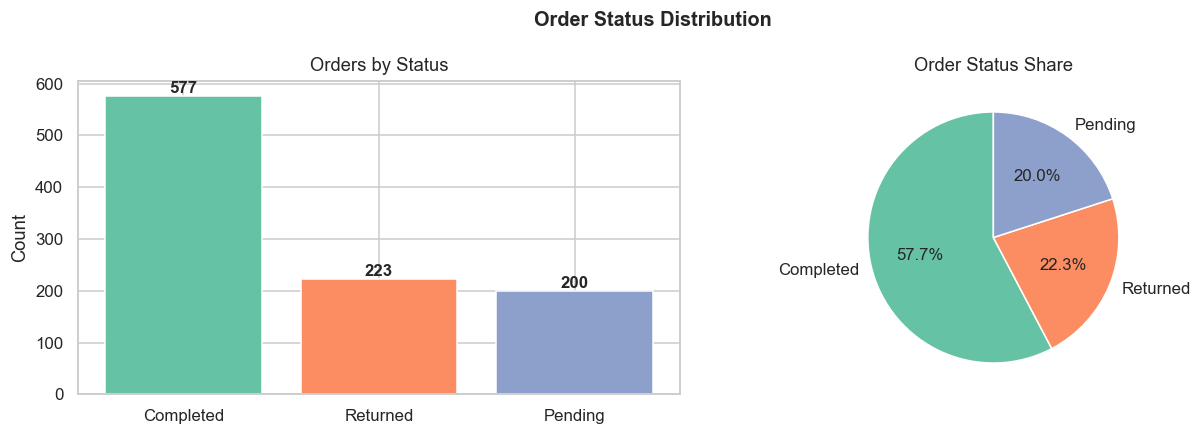

           count   pct
status                
Completed    577  57.7
Returned     223  22.3
Pending      200  20.0


In [4]:
status_counts = df["status"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(status_counts.index, status_counts.values,
            color=sns.color_palette("Set2", 3))
axes[0].set_title("Orders by Status")
axes[0].set_ylabel("Count")
for i, v in enumerate(status_counts.values):
    axes[0].text(i, v + 5, str(v), ha="center", fontweight="bold")

# Pie chart
axes[1].pie(status_counts.values, labels=status_counts.index,
            autopct="%1.1f%%", colors=sns.color_palette("Set2", 3),
            startangle=90)
axes[1].set_title("Order Status Share")

plt.suptitle("Order Status Distribution", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print(status_counts.to_frame("count").assign(pct=lambda x: (x["count"]/x["count"].sum()*100).round(1)))


## 4. Revenue & Profit Overview

In [5]:
completed = df[df["status"] == "Completed"]

metrics = {
    "Total Orders":       len(completed),
    "Total Revenue ($)":  completed["total_amount"].sum(),
    "Total Profit ($)":   completed["profit"].sum(),
    "Avg Order Value ($)":completed["total_amount"].mean(),
    "Avg Profit Margin %":completed["profit_margin_pct"].mean(),
    "Avg Qty per Order":  completed["quantity"].mean(),
}
for k, v in metrics.items():
    if "$" in k:
        print(f"  {k:<25} ${v:>10,.2f}")
    elif "%" in k:
        print(f"  {k:<25} {v:>10.1f}%")
    else:
        print(f"  {k:<25} {v:>10.1f}")


  Total Orders                   577.0
  Total Revenue ($)         $873,860.41
  Total Profit ($)          $360,588.94
  Avg Order Value ($)       $  1,514.49
  Avg Profit Margin %             56.0%
  Avg Qty per Order                5.5


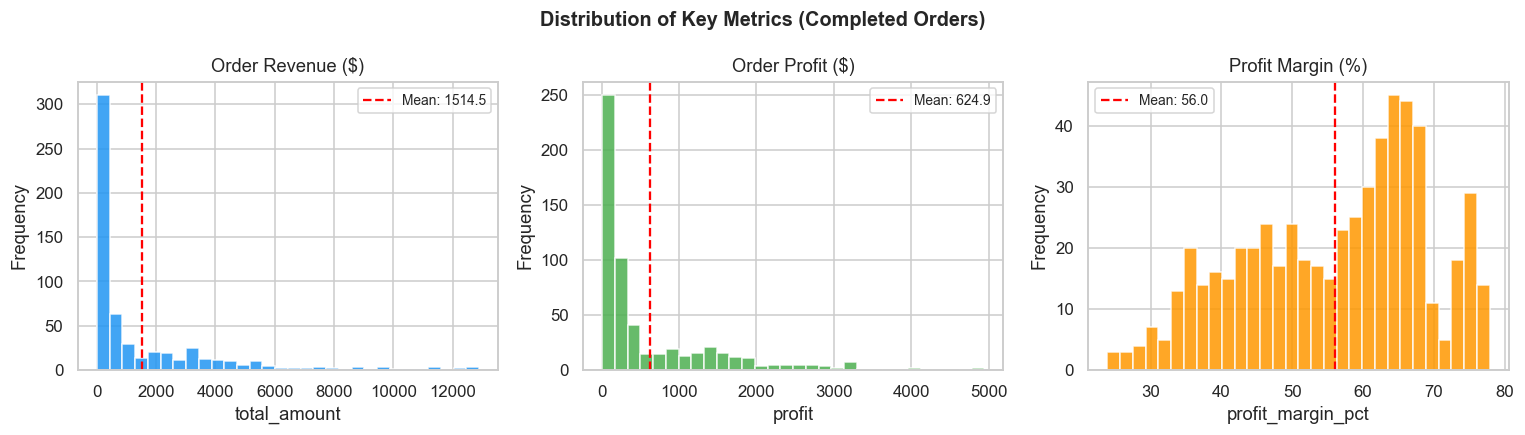

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col, title, color in zip(
    axes,
    ["total_amount", "profit", "profit_margin_pct"],
    ["Order Revenue ($)", "Order Profit ($)", "Profit Margin (%)"],
    ["#2196F3", "#4CAF50", "#FF9800"]
):
    ax.hist(completed[col], bins=30, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(completed[col].mean(), color="red", linestyle="--", label=f"Mean: {completed[col].mean():.1f}")
    ax.set_title(title)
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=9)

plt.suptitle("Distribution of Key Metrics (Completed Orders)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## 5. Monthly Sales Trend

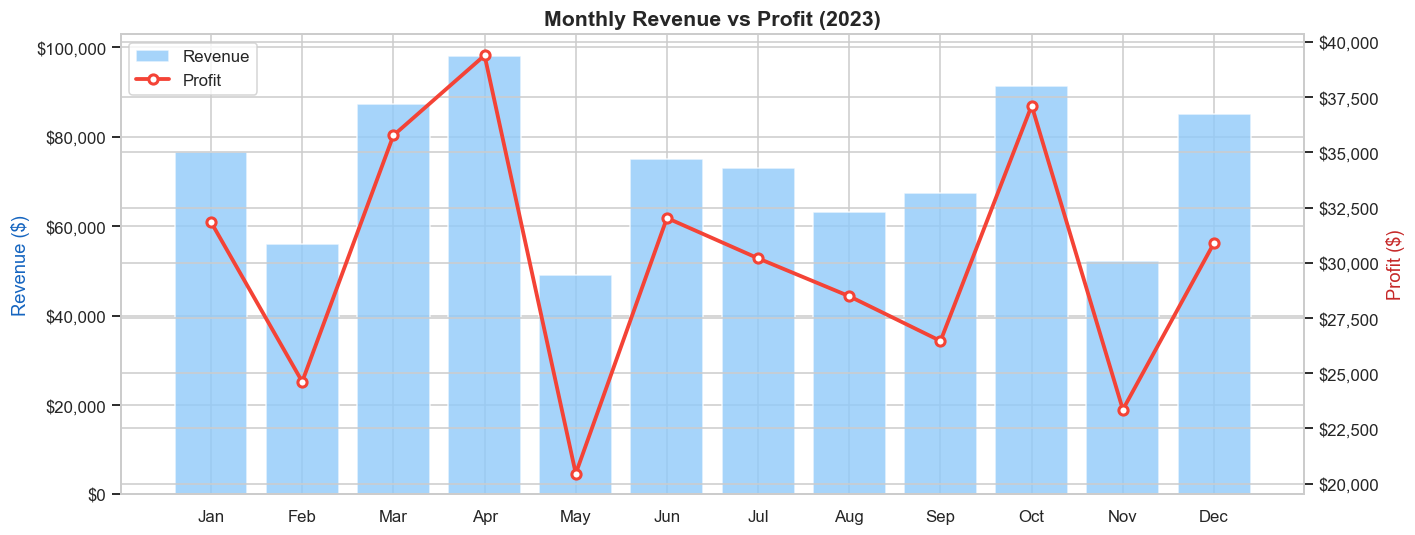

,revenue,profit,orders
label,,,
Jan,76480.50,31840.11,45
Feb,55995.03,24616.77,51
Mar,87208.88,35761.98,50
Apr,97920.00,39385.59,46
May,49035.27,20456.81,59
Jun,75027.37,32025.42,51
Jul,73011.71,30198.64,44
Aug,63246.21,28482.59,42
Sep,67278.58,26459.12,43


In [7]:
monthly = (
    completed.groupby(["year", "month", "month_name"])
    .agg(revenue=("total_amount","sum"), profit=("profit","sum"), orders=("order_id","count"))
    .reset_index()
    .sort_values(["year","month"])
)
monthly["label"] = monthly["month_name"].str[:3]

fig, ax1 = plt.subplots(figsize=(13, 5))
ax2 = ax1.twinx()

ax1.bar(monthly["label"], monthly["revenue"], color="#90CAF9", alpha=0.8, label="Revenue")
ax2.plot(monthly["label"], monthly["profit"], color="#F44336", marker="o",
         linewidth=2.5, label="Profit", markerfacecolor="white", markeredgewidth=2)

ax1.set_ylabel("Revenue ($)", color="#1565C0")
ax2.set_ylabel("Profit ($)", color="#C62828")
ax1.set_title("Monthly Revenue vs Profit (2023)", fontsize=14, fontweight="bold")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.show()
monthly[["label","revenue","profit","orders"]].set_index("label")


## 6. Regional Sales Analysis

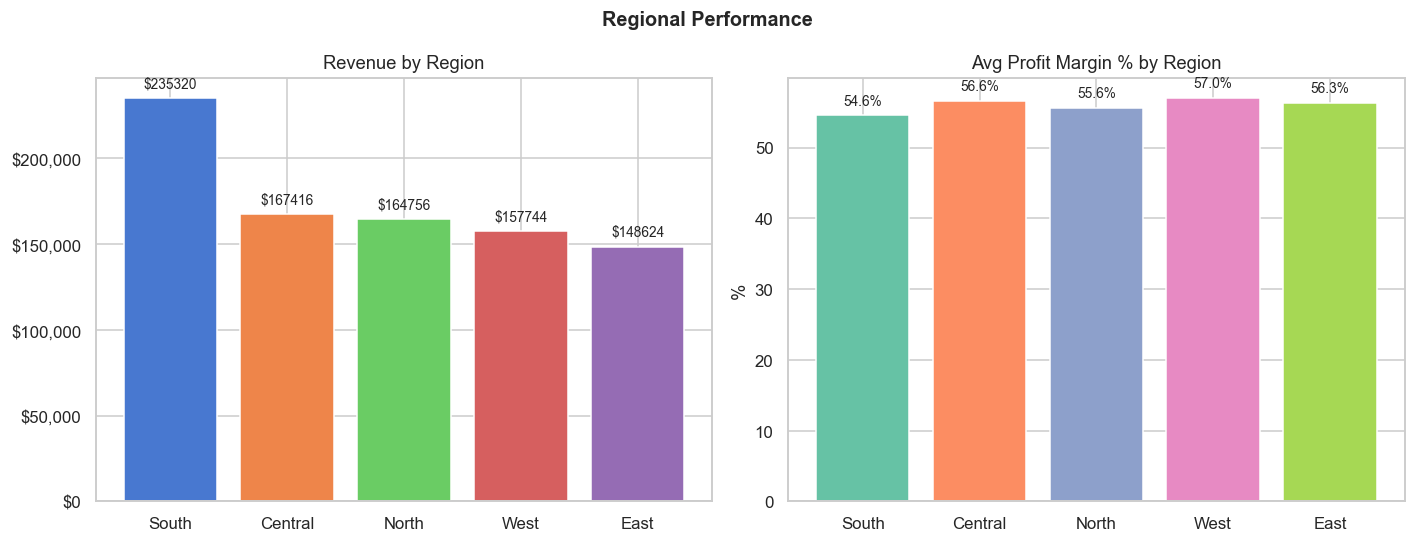

,orders,revenue,profit,avg_margin
region,,,,
South,124,235319.99,94990.90,54.55
Central,111,167415.94,69740.00,56.60
North,110,164756.04,67847.74,55.55
West,131,157744.09,66415.87,57.03
East,101,148624.35,61594.43,56.31


In [8]:
region = completed.groupby("region").agg(
    orders=("order_id","count"),
    revenue=("total_amount","sum"),
    profit=("profit","sum"),
    avg_margin=("profit_margin_pct","mean")
).reset_index().sort_values("revenue", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Revenue by region
bars = axes[0].bar(region["region"], region["revenue"],
                   color=sns.color_palette("muted", len(region)))
axes[0].bar_label(bars, fmt="$%.0f", padding=5, fontsize=9)
axes[0].set_title("Revenue by Region")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

# Avg margin by region
bars2 = axes[1].bar(region["region"], region["avg_margin"],
                    color=sns.color_palette("Set2", len(region)))
axes[1].bar_label(bars2, fmt="%.1f%%", padding=5, fontsize=9)
axes[1].set_title("Avg Profit Margin % by Region")
axes[1].set_ylabel("%")

plt.suptitle("Regional Performance", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

region.set_index("region").round(2)


## 7. Product Performance

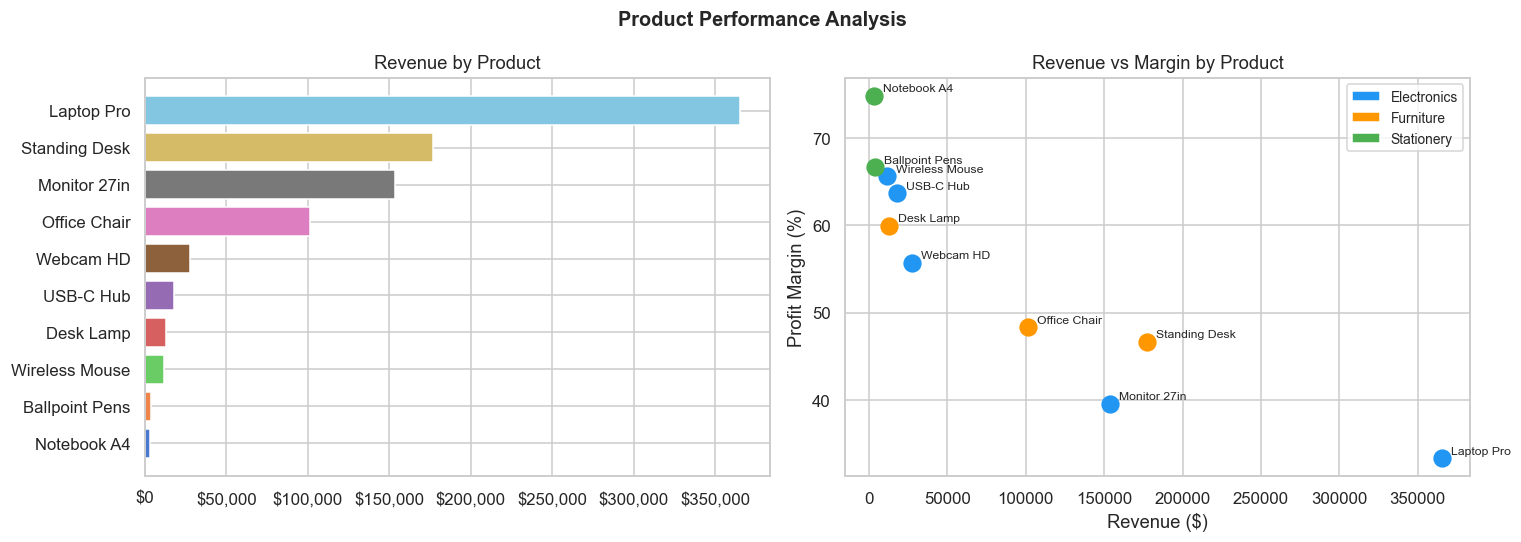

,category,units,revenue,profit,margin
product_name,,,,,
Laptop Pro,Electronics,304,365377.82,121566.72,33.34
Standing Desk,Furniture,296,177051.78,82277.93,46.67
Monitor 27in,Electronics,343,153441.45,60664.30,39.58
Office Chair,Furniture,289,101352.26,49069.35,48.32
Webcam HD,Electronics,302,27523.78,15411.94,55.68
USB-C Hub,Electronics,328,18003.12,11494.76,63.62
Desk Lamp,Furniture,279,12665.90,7652.63,59.92
Wireless Mouse,Electronics,326,11472.80,7558.48,65.58
Ballpoint Pens,Stationery,331,3974.62,2652.37,66.60


In [9]:
product = completed.groupby(["product_name","category"]).agg(
    units=("quantity","sum"),
    revenue=("total_amount","sum"),
    profit=("profit","sum"),
    margin=("profit_margin_pct","mean")
).reset_index().sort_values("revenue", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Revenue ranking
product_sorted = product.sort_values("revenue")
axes[0].barh(product_sorted["product_name"], product_sorted["revenue"],
             color=sns.color_palette("muted", len(product)))
axes[0].set_title("Revenue by Product")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

# Margin vs Revenue scatter
colors = {"Electronics": "#2196F3", "Furniture": "#FF9800", "Stationery": "#4CAF50"}
for _, row in product.iterrows():
    axes[1].scatter(row["revenue"], row["margin"],
                    color=colors.get(row["category"], "gray"), s=120, zorder=5)
    axes[1].annotate(row["product_name"], (row["revenue"], row["margin"]),
                     textcoords="offset points", xytext=(6, 3), fontsize=8)
axes[1].set_xlabel("Revenue ($)")
axes[1].set_ylabel("Profit Margin (%)")
axes[1].set_title("Revenue vs Margin by Product")

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=cat) for cat, c in colors.items()]
axes[1].legend(handles=legend_elements, fontsize=9)

plt.suptitle("Product Performance Analysis", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

product.set_index("product_name").round(2)


## 8. Customer Behaviour

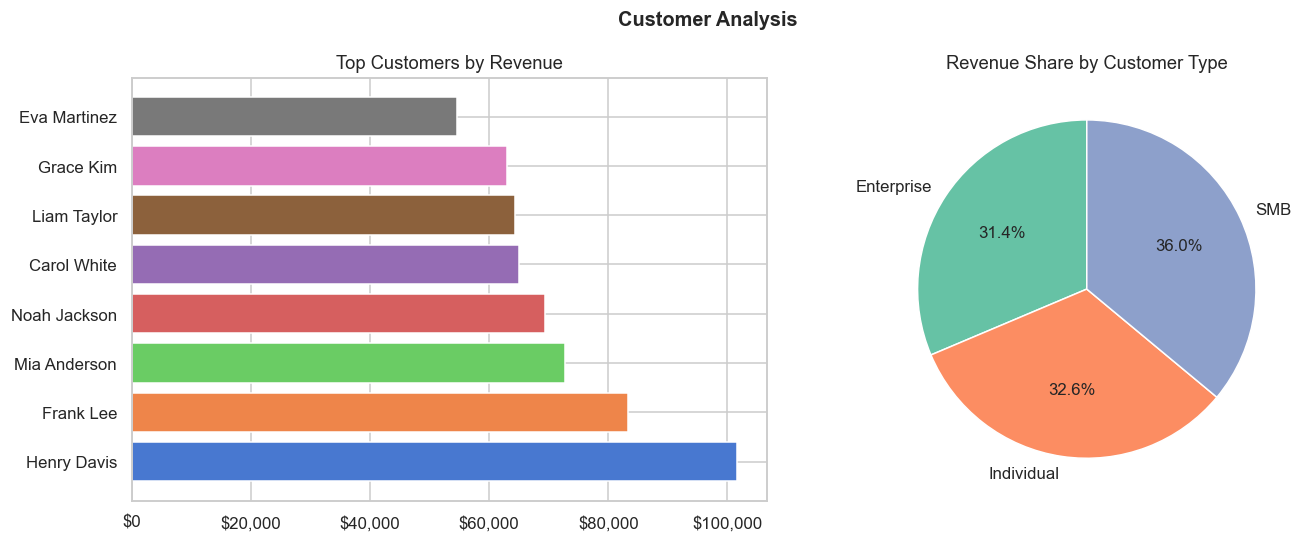

,customer_type,orders,total_spent,avg_order,profit
customer_name,,,,,
Henry Davis,SMB,46,101648.28,2209.75,41552.18
Frank Lee,Individual,44,83272.35,1892.55,32184.51
Mia Anderson,SMB,41,72735.21,1774.03,28025.37
Noah Jackson,Enterprise,36,69367.51,1926.88,29438.92
Carol White,Enterprise,46,65000.57,1413.06,26722.35
Liam Taylor,Individual,44,64350.92,1462.52,25947.32
Grace Kim,Enterprise,39,63039.19,1616.39,26298.48
Eva Martinez,SMB,44,54546.07,1239.68,22642.45
Olivia Harris,Individual,34,49139.23,1445.27,19143.05


In [10]:
customer = completed.groupby(["customer_name","customer_type"]).agg(
    orders=("order_id","count"),
    total_spent=("total_amount","sum"),
    avg_order=("total_amount","mean"),
    profit=("profit","sum")
).reset_index().sort_values("total_spent", ascending=False)

# Customer type segments
by_type = completed.groupby("customer_type").agg(
    orders=("order_id","count"),
    revenue=("total_amount","sum"),
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Top customers bar
top10 = customer.head(8)
axes[0].barh(top10["customer_name"], top10["total_spent"],
             color=sns.color_palette("muted", len(top10)))
axes[0].set_title("Top Customers by Revenue")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

# Revenue by customer type
axes[1].pie(by_type["revenue"], labels=by_type["customer_type"],
            autopct="%1.1f%%", colors=sns.color_palette("Set2", 3), startangle=90)
axes[1].set_title("Revenue Share by Customer Type")

plt.suptitle("Customer Analysis", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

customer.head(10).set_index("customer_name").round(2)


## 9. Correlation Analysis

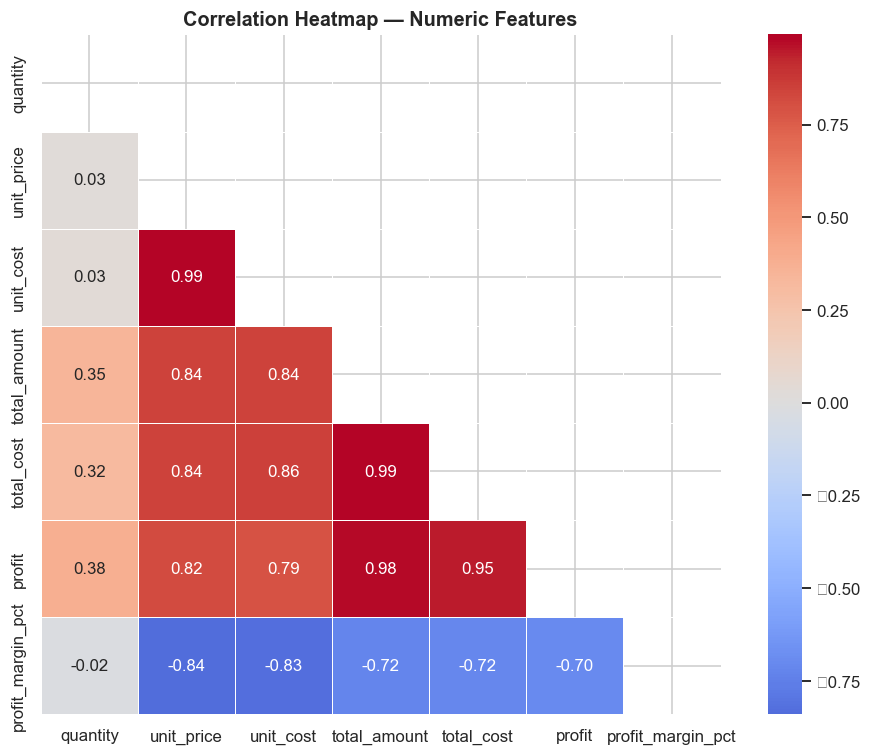

In [11]:
numeric_cols = ["quantity", "unit_price", "unit_cost",
                "total_amount", "total_cost", "profit", "profit_margin_pct"]
corr = completed[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            mask=mask, ax=ax, linewidths=0.5, square=True)
ax.set_title("Correlation Heatmap — Numeric Features", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## 10. Key Insights Summary

After exploring the data, here are the main takeaways:

| Area | Finding |
|------|---------|
| **Revenue** | ~77% of orders are Completed; ~13% Returned |
| **Top Product** | Laptop Pro drives the most revenue by far |
| **Best Margin** | Stationery has the highest profit margin % |
| **Top Region** | Revenue is spread fairly evenly across regions |
| **Customer Segments** | Enterprise customers have the highest average order value |
| **Seasonality** | Review monthly trend chart for peak months |

> 💡 **Next steps**: Connect to MySQL, run `sql/analytics_queries.sql` for deeper SQL-based analysis.
